# EDA — Overview General
Validación visual del análisis en `src/eda/01_overview.py`.  
Cubre: shapes, nulos, balance de clases, demographics, transacciones, logs de escucha.

In [8]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.eda.overview_01 import (
    load_train, load_members, load_transactions, load_user_logs_sample,
    analyze_train, analyze_members, analyze_transactions, analyze_user_logs,
    analyze_key_coverage,
    plot_churn_balance, plot_age_distribution,
    plot_transaction_prices, plot_listening_behavior,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Target Variable — Train

In [9]:
train, train_v2 = load_train()
train_results = analyze_train(train, train_v2)

══════════════════════════════════════════════════
TRAIN
  train shape      : (992931, 2)
  train_v2 shape   : (970960, 2)
  churn rate train : 6.39%
  churn rate v2    : 8.99%
  overlap usuarios : 881701


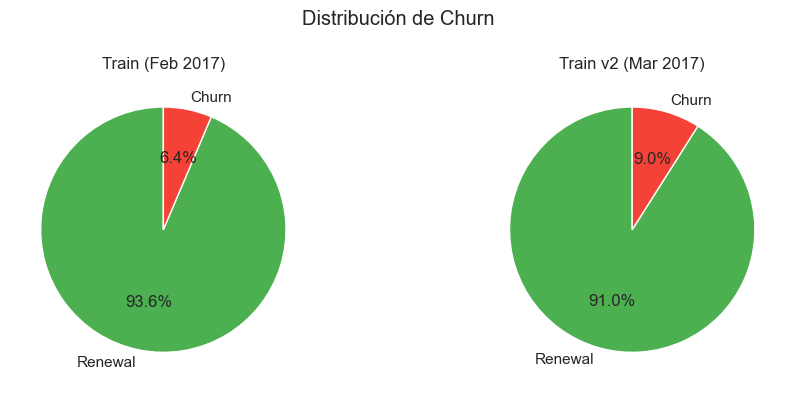

In [10]:
plot_churn_balance(train, train_v2)

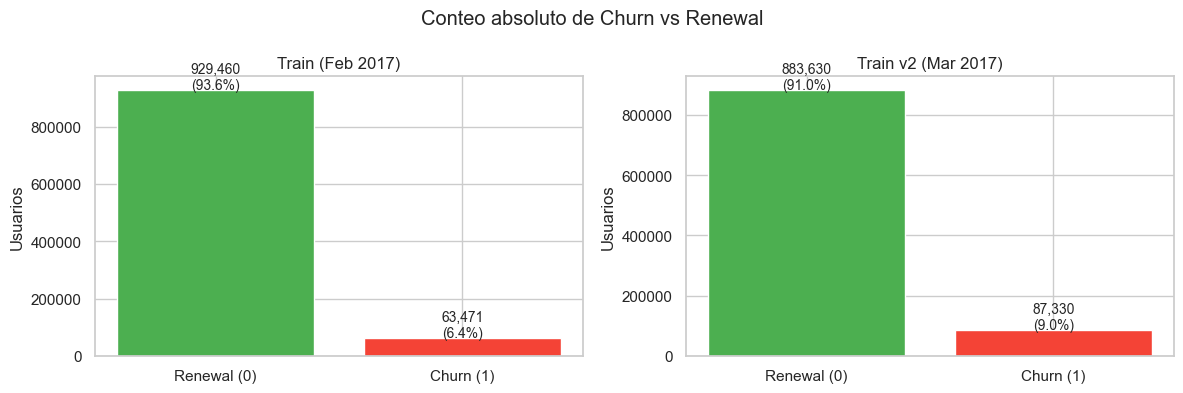

In [11]:
# Distribución detallada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train, train_v2], ['Train (Feb 2017)', 'Train v2 (Mar 2017)']):
    counts = df['is_churn'].value_counts()
    ax.bar(['Renewal (0)', 'Churn (1)'], counts.values, color=['#4CAF50', '#F44336'])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('Usuarios')
plt.suptitle('Conteo absoluto de Churn vs Renewal')
plt.tight_layout()
plt.show()

## 2. Members — Demografía

In [12]:
members = load_members()
members_results = analyze_members(members)

══════════════════════════════════════════════════
MEMBERS
  shape            : (6769473, 6)
  nulos:
msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64
  edad válida (<100, >0): 32.85% de filas
  género:
gender
NaN       4429505
male      1195355
female    1144613
Name: count, dtype: int64


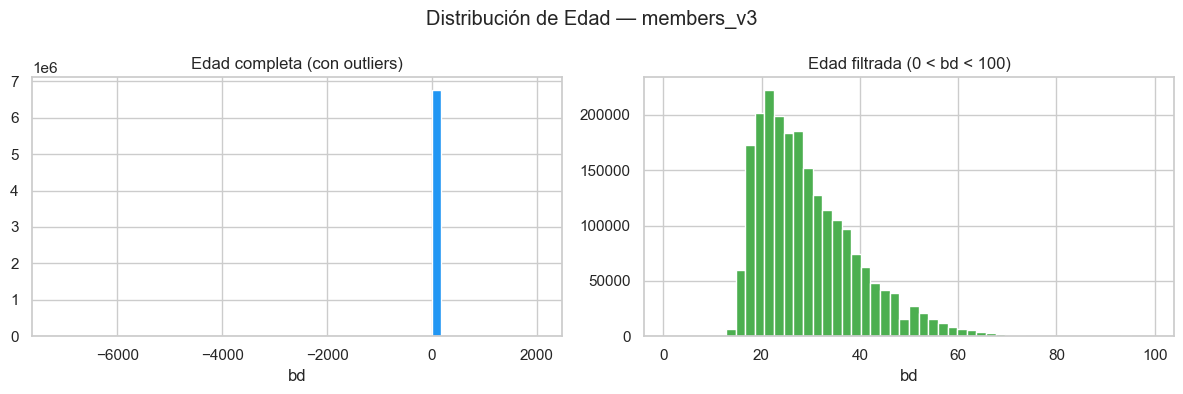

In [13]:
plot_age_distribution(members)

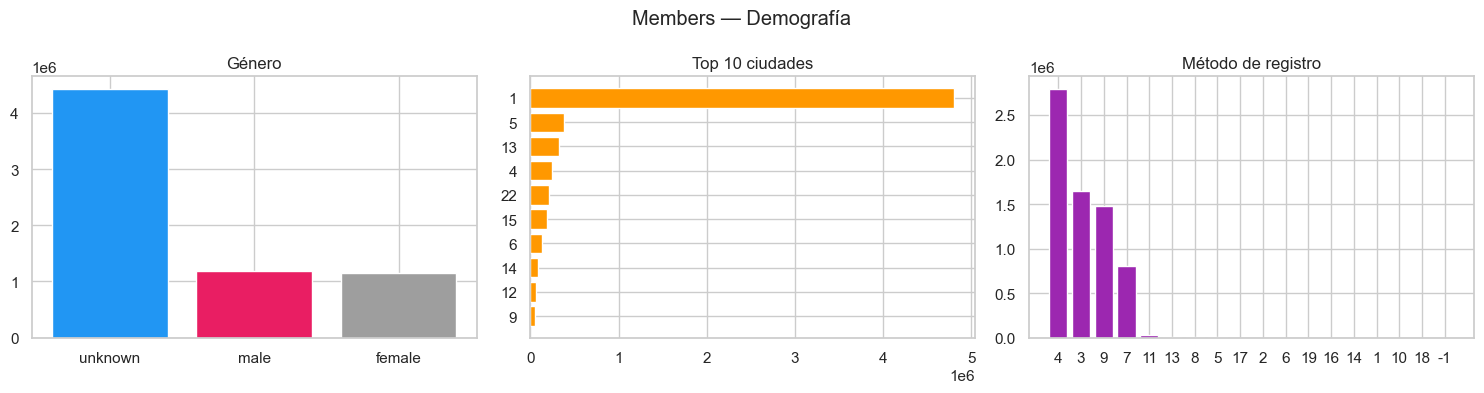

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Género — fillna evita float en el índice al graficar
gender = members['gender'].fillna('unknown').value_counts()
palette = ['#2196F3', '#E91E63', '#9E9E9E']
axes[0].bar(gender.index.tolist(), gender.values, color=palette[:len(gender)])
axes[0].set_title('Género')

# Ciudad top 10
city = members['city'].value_counts().head(10)
axes[1].barh([str(x) for x in city.index], city.values, color='#FF9800')
axes[1].set_title('Top 10 ciudades')
axes[1].invert_yaxis()

# Método de registro
reg = members['registered_via'].value_counts()
axes[2].bar([str(x) for x in reg.index], reg.values, color='#9C27B0')
axes[2].set_title('Método de registro')

plt.suptitle('Members — Demografía')
plt.tight_layout()
plt.show()

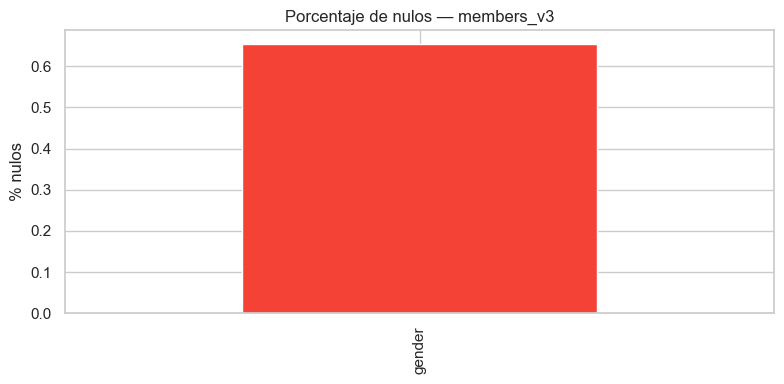

In [15]:
# Mapa de nulos
nulls = members.isnull().mean().sort_values(ascending=False)
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    nulls.plot(kind='bar', color='#F44336', figsize=(8, 4))
    plt.title('Porcentaje de nulos — members_v3')
    plt.ylabel('% nulos')
    plt.tight_layout()
    plt.show()
else:
    print('Sin valores nulos en members_v3')

## 3. Transactions

In [16]:
transactions = load_transactions()
tx_results = analyze_transactions(transactions)

══════════════════════════════════════════════════
TRANSACTIONS
  shape            : (22978755, 9)
  usuarios únicos  : 2,426,143
  auto-renew rate  : 84.78%
  cancel rate      : 3.88%
  nulos:
msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64


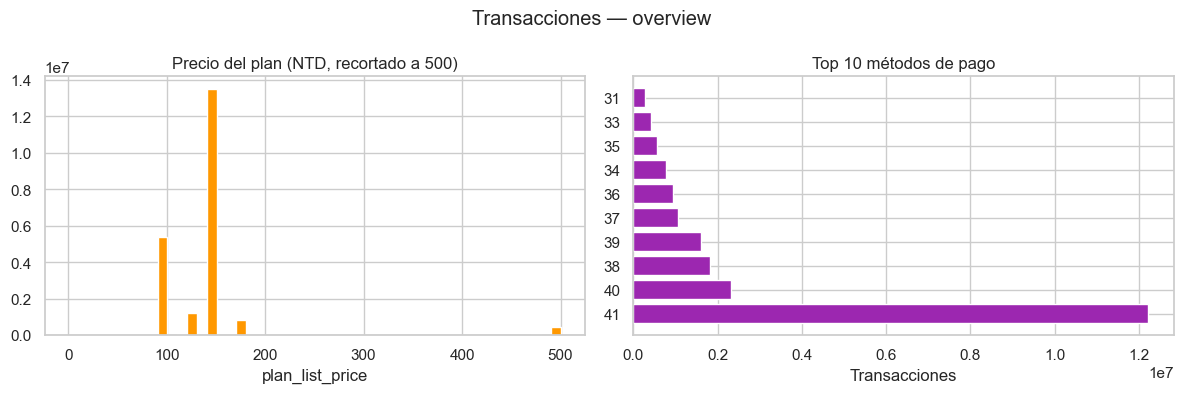

In [17]:
plot_transaction_prices(transactions)

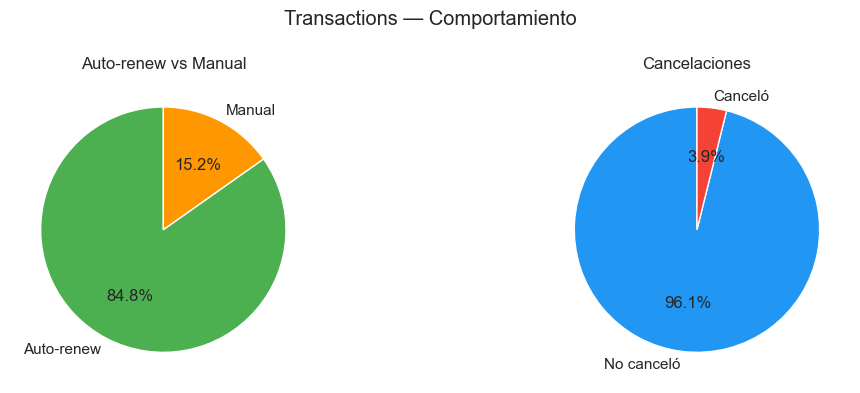

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Auto-renew vs manual
ar = transactions['is_auto_renew'].value_counts()
axes[0].pie(ar.values, labels=['Auto-renew', 'Manual'], autopct='%1.1f%%',
            colors=['#4CAF50', '#FF9800'], startangle=90)
axes[0].set_title('Auto-renew vs Manual')

# Cancelaciones
cancel = transactions['is_cancel'].value_counts()
axes[1].pie(cancel.values, labels=['No canceló', 'Canceló'], autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Cancelaciones')

plt.suptitle('Transactions — Comportamiento')
plt.tight_layout()
plt.show()

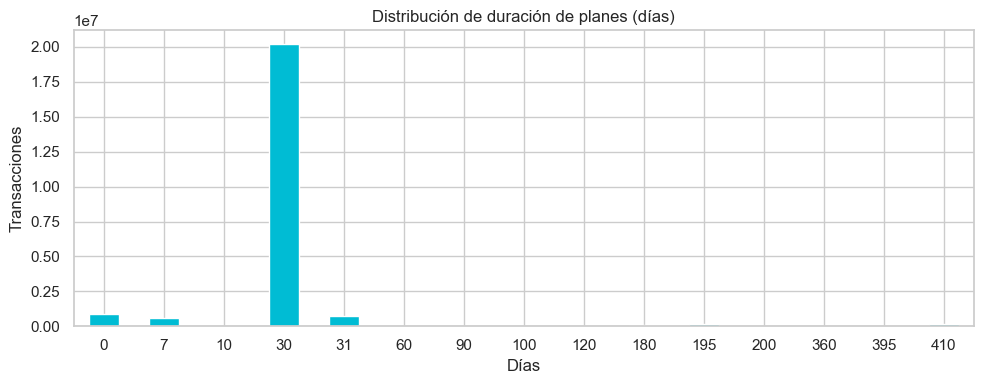

In [19]:
# Duración de planes
plan_days = transactions['payment_plan_days'].value_counts().head(15).sort_index()
plan_days.plot(kind='bar', color='#00BCD4', figsize=(10, 4), edgecolor='white')
plt.title('Distribución de duración de planes (días)')
plt.xlabel('Días')
plt.ylabel('Transacciones')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. User Logs (muestra 500K filas)

In [20]:
logs = load_user_logs_sample(nrows=500_000)
logs_results = analyze_user_logs(logs)

══════════════════════════════════════════════════
USER LOGS (muestra)
  shape            : (500000, 9)
  usuarios únicos  : 100,408
  rango de fechas  : (np.int64(20150101), np.int64(20170228))
  nulos:
msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64


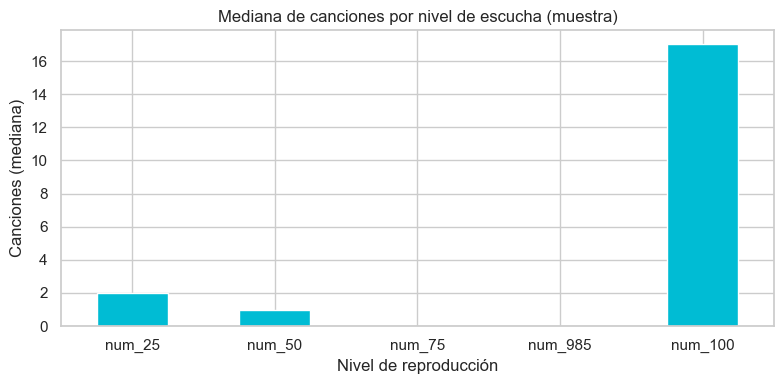

In [21]:
plot_listening_behavior(logs)

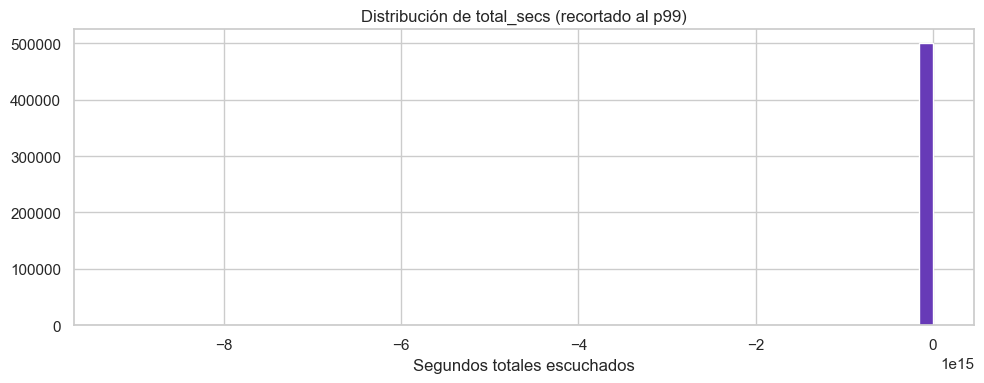

In [22]:
# Distribución de total_secs
fig, ax = plt.subplots(figsize=(10, 4))
logs['total_secs'].clip(upper=logs['total_secs'].quantile(0.99)).hist(
    bins=60, ax=ax, color='#673AB7', edgecolor='white'
)
ax.set_title('Distribución de total_secs (recortado al p99)')
ax.set_xlabel('Segundos totales escuchados')
plt.tight_layout()
plt.show()

## 5. Cobertura de Keys entre tablas

══════════════════════════════════════════════════
COBERTURA DE KEYS
  train users en members     : 88.34%
  train users en transactions: 100.00%


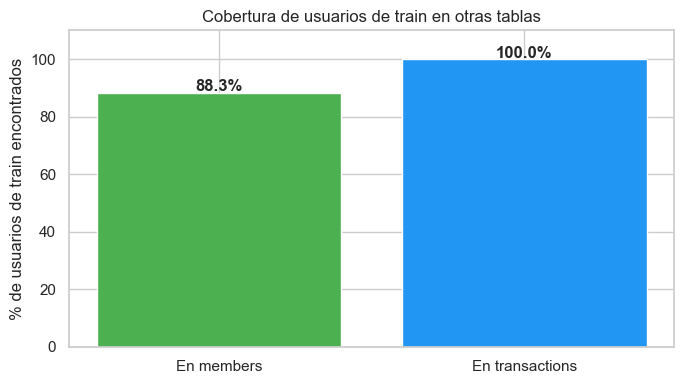

In [23]:
coverage = analyze_key_coverage(train, members, transactions)

labels = ['En members', 'En transactions']
values = [coverage['train_in_members'], coverage['train_in_transactions']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, [v * 100 for v in values], color=['#4CAF50', '#2196F3'], edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('% de usuarios de train encontrados')
ax.set_title('Cobertura de usuarios de train en otras tablas')
plt.tight_layout()
plt.show()

## 6. Resumen de hallazgos

In [24]:
print('═' * 55)
print('RESUMEN EDA — OVERVIEW')
print('═' * 55)
print(f"Churn rate train    : {train_results['train_churn_rate']:.2%}")
print(f"Churn rate train_v2 : {train_results['train_v2_churn_rate']:.2%}")
print(f"Overlap usuarios    : {train_results['user_overlap']:,}")
print(f"Age válida (0-100)  : {members_results['age_valid_pct']:.2%}")
print(f"Auto-renew rate     : {tx_results['auto_renew_rate']:.2%}")
print(f"Cancel rate         : {tx_results['cancel_rate']:.2%}")
print(f"Train en members    : {coverage['train_in_members']:.2%}")
print(f"Train en transact.  : {coverage['train_in_transactions']:.2%}")

═══════════════════════════════════════════════════════
RESUMEN EDA — OVERVIEW
═══════════════════════════════════════════════════════
Churn rate train    : 6.39%
Churn rate train_v2 : 8.99%
Overlap usuarios    : 881,701
Age válida (0-100)  : 32.85%
Auto-renew rate     : 84.78%
Cancel rate         : 3.88%
Train en members    : 88.34%
Train en transact.  : 100.00%
